#  Face Recognition with `face_recognition` Library

This notebook demonstrates **face detection** and **face recognition** using the `face_recognition` library (built on top of `dlib`).

###  What we'll cover:
1. Install dependencies
2. Detect faces in an image
3. Encode known faces
4. Compare and recognize faces in a new image
5. Draw bounding boxes with names

## 1. 🔧 Install Dependencies

In [1]:
# Install required libraries
!pip install face_recognition cmake dlib -q
!pip install opencv-python-headless matplotlib -q
print(" All dependencies installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 15.5 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
 All dependencies installed!


## 2. Import Libraries

In [2]:
import face_recognition
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw
import urllib.request
import os

print(" Libraries imported successfully!")

 Libraries imported successfully!


## 3.  Download Sample Images

We'll use publicly available images of well-known public figures for demonstration.
You can also **upload your own images** using the cell below.

In [9]:
import os
import requests

os.makedirs('images', exist_ok=True)

images = {
    'obama.jpg': 'https://upload.wikimedia.org/wikipedia/commons/thumb/8/8d/President_Barack_Obama.jpg/250px-President_Barack_Obama.jpg',
    'biden.jpg': 'https://upload.wikimedia.org/wikipedia/commons/thumb/6/68/Joe_Biden_presidential_portrait.jpg/250px-Joe_Biden_presidential_portrait.jpg',
    'test_group.jpg': 'https://upload.wikimedia.org/wikipedia/commons/thumb/a/a7/Camponotus_flavomarginatus_ant.jpg/250px-Camponotus_flavomarginatus_ant.jpg'
}

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:109.0) Gecko/20100101 Firefox/115.0'
}

for fname, url in images.items():
    try:
        response = requests.get(url, headers=headers)
        response.raise_for_status() # Check for HTTP errors
        with open(f'images/{fname}', 'wb') as f:
            f.write(response.content)
        print(f"Downloaded: {fname}")
    except Exception as e:
        print(f"Failed to download {fname}: {e}")

print("\nSample images downloaded to /images/ folder")   

Downloaded: obama.jpg
Downloaded: biden.jpg
Downloaded: test_group.jpg

Sample images downloaded to /images/ folder


### (Optional) Upload Your Own Images

In [10]:
# Uncomment to upload images from your local machine
# from google.colab import files
# uploaded = files.upload()
# for filename in uploaded.keys():
#     print(f'Uploaded: {filename}')

## 4.  Detect Faces in an Image

 Found 1 face(s) in images/obama.jpg


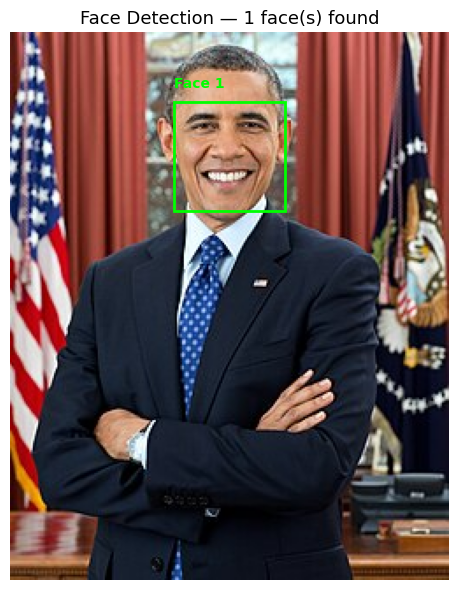

In [11]:
def detect_and_display_faces(image_path):
    """Detect faces in an image and display bounding boxes."""
    # Load the image
    image = face_recognition.load_image_file(image_path)
    
    # Find all face locations in the image
    face_locations = face_recognition.face_locations(image)
    
    print(f" Found {len(face_locations)} face(s) in {image_path}")
    
    # Display image with bounding boxes
    fig, ax = plt.subplots(1, figsize=(8, 6))
    ax.imshow(image)
    
    for i, (top, right, bottom, left) in enumerate(face_locations):
        width = right - left
        height = bottom - top
        rect = patches.Rectangle(
            (left, top), width, height,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(left, top - 8, f'Face {i+1}', color='lime', fontsize=10, weight='bold')
    
    ax.axis('off')
    ax.set_title(f'Face Detection — {len(face_locations)} face(s) found', fontsize=13)
    plt.tight_layout()
    plt.show()
    
    return face_locations

# Run face detection on Obama's photo
face_locations = detect_and_display_faces('images/obama.jpg')

## 5.  Facial Landmark Detection

Detect key facial features: eyes, nose, mouth, chin, eyebrows.

Found landmarks for 1 face(s)


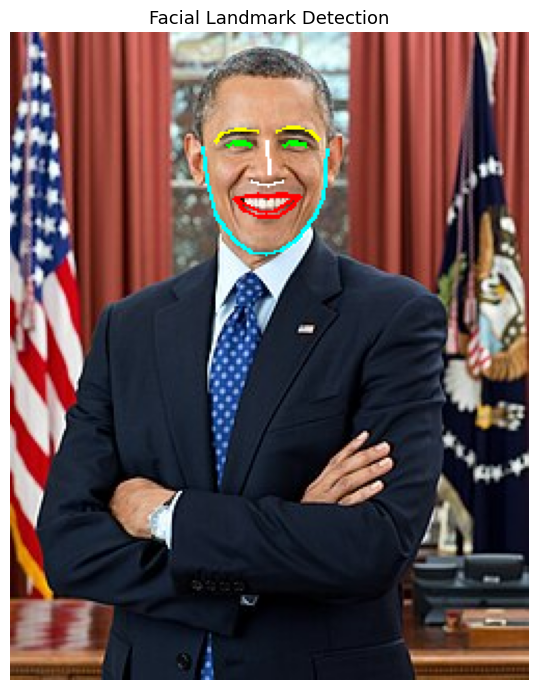

In [12]:
def show_facial_landmarks(image_path):
    """Detect and visualize facial landmarks."""
    image = face_recognition.load_image_file(image_path)
    face_landmarks_list = face_recognition.face_landmarks(image)
    
    print(f"Found landmarks for {len(face_landmarks_list)} face(s)")
    
    pil_image = Image.fromarray(image)
    draw = ImageDraw.Draw(pil_image)
    
    colors = {
        'chin': 'cyan', 'left_eyebrow': 'yellow', 'right_eyebrow': 'yellow',
        'nose_bridge': 'white', 'nose_tip': 'white',
        'left_eye': 'lime', 'right_eye': 'lime',
        'top_lip': 'red', 'bottom_lip': 'red'
    }
    
    for face_landmarks in face_landmarks_list:
        for feature, color in colors.items():
            if feature in face_landmarks:
                draw.line(face_landmarks[feature], fill=color, width=2)
    
    plt.figure(figsize=(7, 7))
    plt.imshow(pil_image)
    plt.axis('off')
    plt.title('Facial Landmark Detection', fontsize=13)
    plt.tight_layout()
    plt.show()

show_facial_landmarks('images/obama.jpg')

## 6.  Encode Known Faces

Generate 128-dimensional face encodings for known individuals.

In [13]:
def encode_face(image_path, name):
    """Encode a known face from an image file."""
    image = face_recognition.load_image_file(image_path)
    encodings = face_recognition.face_encodings(image)
    
    if len(encodings) == 0:
        print(f" No face found in {image_path}!")
        return None, None
    
    print(f" Encoded face for: {name} (encoding shape: {encodings[0].shape})")
    return encodings[0], name

# Encode known faces
known_face_encodings = []
known_face_names = []

enc1, name1 = encode_face('images/obama.jpg', 'Barack Obama')
enc2, name2 = encode_face('images/biden.jpg', 'Joe Biden')

for enc, name in [(enc1, name1), (enc2, name2)]:
    if enc is not None:
        known_face_encodings.append(enc)
        known_face_names.append(name)

print(f"\n Encoded {len(known_face_encodings)} known face(s): {known_face_names}")

 Encoded face for: Barack Obama (encoding shape: (128,))
 Encoded face for: Joe Biden (encoding shape: (128,))

 Encoded 2 known face(s): ['Barack Obama', 'Joe Biden']


## 7.  Recognize Faces in a New Image

 Analyzing: images/obama.jpg
 Detected 1 face(s)
  → Barack Obama (confidence: 100.0%)


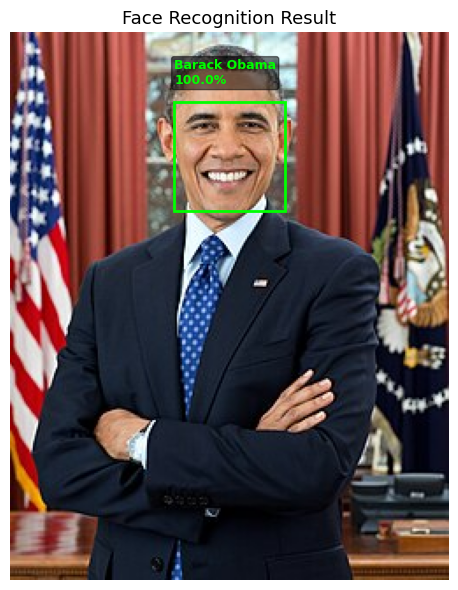

In [14]:
def recognize_faces(test_image_path, known_encodings, known_names, tolerance=0.6):
    """Compare faces in a test image against known encodings."""
    test_image = face_recognition.load_image_file(test_image_path)
    
    # Detect all face locations and encodings in the test image
    face_locations = face_recognition.face_locations(test_image)
    face_encodings = face_recognition.face_encodings(test_image, face_locations)
    
    print(f" Analyzing: {test_image_path}")
    print(f" Detected {len(face_locations)} face(s)")
    
    recognized = []
    
    for face_encoding in face_encodings:
        # Compare with known faces
        matches = face_recognition.compare_faces(known_encodings, face_encoding, tolerance=tolerance)
        face_distances = face_recognition.face_distance(known_encodings, face_encoding)
        
        name = "Unknown"
        confidence = 0.0
        
        if True in matches:
            best_match_idx = np.argmin(face_distances)
            if matches[best_match_idx]:
                name = known_names[best_match_idx]
                confidence = (1 - face_distances[best_match_idx]) * 100
        
        recognized.append((name, confidence))
        print(f"  → {name} (confidence: {confidence:.1f}%)")
    
    # Visualize results
    fig, ax = plt.subplots(1, figsize=(8, 6))
    ax.imshow(test_image)
    
    for (top, right, bottom, left), (name, conf) in zip(face_locations, recognized):
        color = 'lime' if name != 'Unknown' else 'red'
        rect = patches.Rectangle(
            (left, top), right - left, bottom - top,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        label = f"{name}\n{conf:.1f}%" if name != 'Unknown' else 'Unknown'
        ax.text(left, top - 10, label, color=color, fontsize=9, weight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5))
    
    ax.axis('off')
    ax.set_title('Face Recognition Result', fontsize=13)
    plt.tight_layout()
    plt.show()
    
    return recognized

# Test recognition on Obama's image (should recognize him)
results = recognize_faces('images/obama.jpg', known_face_encodings, known_face_names)

## 8.  Face Distance Comparison

Lower distance = more similar faces (threshold is typically 0.6)

 Face Distance Comparison:
   Barack Obama vs Joe Biden
   Distance: 0.8576
   Match:  Different people


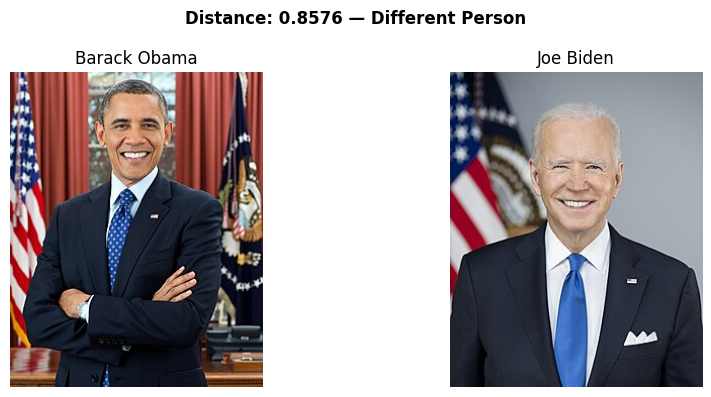

In [15]:
if len(known_face_encodings) >= 2:
    distance = face_recognition.face_distance([known_face_encodings[0]], known_face_encodings[1])[0]
    
    print(" Face Distance Comparison:")
    print(f"   {known_face_names[0]} vs {known_face_names[1]}")
    print(f"   Distance: {distance:.4f}")
    print(f"   Match: {' Same person' if distance < 0.6 else ' Different people'}")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for i, (ax, img_path, name) in enumerate(zip(
        axes,
        ['images/obama.jpg', 'images/biden.jpg'],
        known_face_names
    )):
        img = face_recognition.load_image_file(img_path)
        ax.imshow(img)
        ax.set_title(name, fontsize=12)
        ax.axis('off')
    
    plt.suptitle(f'Distance: {distance:.4f} — {"Same" if distance < 0.6 else "Different"} Person',
                 fontsize=12, weight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Need at least 2 encoded faces to compare.")